In [2]:
import numpy as np 
import pandas as pd
from scipy import ndimage 
from scipy.cluster import hierarchy 
from scipy.spatial import distance_matrix 
from matplotlib import pyplot as plt 
from sklearn import manifold, datasets 
from sklearn.cluster import AgglomerativeClustering 
from sklearn.datasets import make_blobs 

### Generating Random Data
#### using the make_blobs class

In [3]:
x1,y1=make_blobs(n_samples=100,centers=[[4,4],[-2,-1],[1,1],[10,4]], cluster_std=0.9)
print(x1[0:5])
print(y1[0:5])

[[ 3.31672666  4.75337103]
 [ 0.44281856  0.60356995]
 [10.18179657  3.15882322]
 [10.09147534  2.6492069 ]
 [10.1303431   3.6316714 ]]
[0 2 3 3 3]


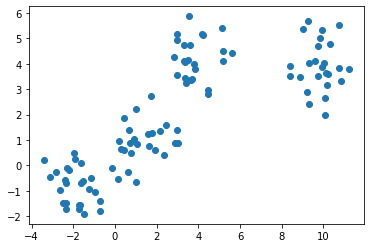

In [4]:
plt.scatter(x1[:,0],x1[:,1],marker='o')

Agglomerative Clustering

In [5]:
model=AgglomerativeClustering(n_clusters=4,linkage='average')

In [6]:
model.fit(x1,y1)

AgglomerativeClustering(linkage='average', n_clusters=4)

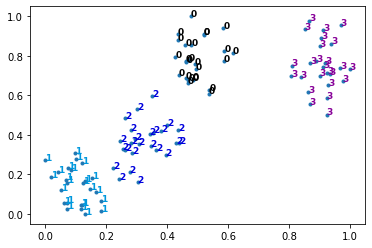

In [7]:
plt.figure(figsize=(6,4))

x_min,x_max=np.min(x1,axis=0),np.max(x1,axis=0)

x1=(x1-x_min)/(x_max-x_min)
# give x1 between 0 and 1

for i in range(x1.shape[0]):
    plt.text(x1[i,0],x1[i,1],str(y1[i]),
             color=plt.cm.nipy_spectral(model.labels_[i]/10.),
             fontdict={'weight':'bold','size':9})


# Remove the x ticks, y ticks, x and y axis
#plt.xticks([])
#plt.yticks([])
#plt.axis('off')

plt.scatter(x1[:,0], x1[:,1], marker='.')
plt.show()

### Dendrogram Associated for the Agglomerative Hierarchical Clusterin

In [8]:
dist_matrix=distance_matrix(x1,x1)
print(dist_matrix)

[[0.         0.56845827 0.51270696 ... 0.83952375 0.45833878 0.56840695]
 [0.56845827 0.         0.74320378 ... 0.29124961 0.88809514 0.00964737]
 [0.51270696 0.74320378 0.         ... 1.02503131 0.27805689 0.74978431]
 ...
 [0.83952375 0.29124961 1.02503131 ... 0.         1.17933879 0.28722565]
 [0.45833878 0.88809514 0.27805689 ... 1.17933879 0.         0.89235735]
 [0.56840695 0.00964737 0.74978431 ... 0.28722565 0.89235735 0.        ]]


Using the <b> linkage </b> class from hierarchy, pass in the parameters

In [9]:
z=hierarchy.linkage(dist_matrix,'complete')

C:\Users\bgc\AppData\Local\Temp/ipykernel_11188/1811462054.py:1: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  z=hierarchy.linkage(dist_matrix,'complete')


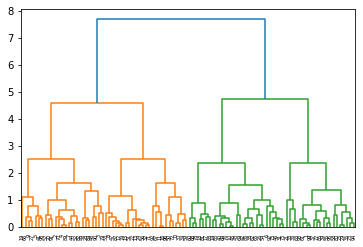

In [10]:
dendro=hierarchy.dendrogram(z)

## Practice
We used **complete** linkage for our case, change it to **average**, **single**, and **centroid** linkage to see how the dendogram changes.<br/>
single ==> min , complete ==> max

C:\Users\bgc\AppData\Local\Temp/ipykernel_11188/1851970649.py:1: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  z=hierarchy.linkage(dist_matrix,'average')


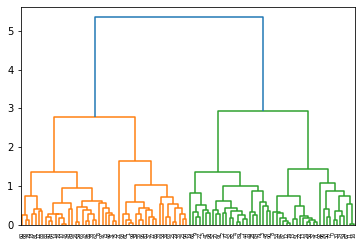

In [11]:
z=hierarchy.linkage(dist_matrix,'average')
dendro=hierarchy.dendrogram(z)

C:\Users\bgc\AppData\Local\Temp/ipykernel_11188/3114294156.py:1: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  z=hierarchy.linkage(dist_matrix,'single')


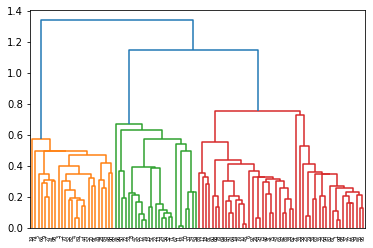

In [12]:
z=hierarchy.linkage(dist_matrix,'single')
dendro=hierarchy.dendrogram(z)

C:\Users\bgc\AppData\Local\Temp/ipykernel_11188/4148515001.py:1: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  z=hierarchy.linkage(dist_matrix,'centroid')


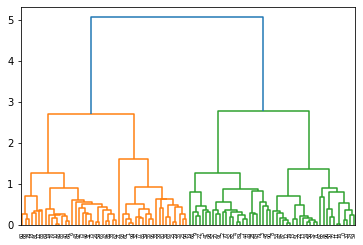

In [13]:
z=hierarchy.linkage(dist_matrix,'centroid')
dendro=hierarchy.dendrogram(z)

## Clustering on Vehicle dataset

In [14]:
cars_clus='cars_clus.csv'
df=pd.read_csv(cars_clus)
print("shape of dataset:",df.shape)
df.head(5)

shape of dataset: (159, 16)


,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.000,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2.828,0.0
1,Acura,TL,39.384,19.875,0.000,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,3.673,0.0
2,Acura,CL,14.114,18.225,0.000,$null$,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,2.647,0.0
3,Acura,RL,8.588,29.725,0.000,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2.150,0.0
4,Audi,A4,20.397,22.255,0.000,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,3.015,0.0


### Data Cleaning

In [15]:
print ("shape of dataset before cleaning:", df.shape)

df[['sales','resale','type','price','engine_s','horsepow','wheelbas',
'width','length','curb_wgt','fuel_cap','mpg',
'lnsales']]=df[['sales','resale','type','price',
'engine_s','horsepow','wheelbas','width','length','curb_wgt',
'fuel_cap','mpg','lnsales']].apply(pd.to_numeric,errors='coerce')

df=df.dropna()
df=df.reset_index(drop=True)
print("shape of dataset after cleaning:", df.shape)
df.head(5)

shape of dataset before cleaning: (159, 16)
shape of dataset after cleaning: (117, 16)


,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.0,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2.828,0.0
1,Acura,TL,39.384,19.875,0.0,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,3.673,0.0
2,Acura,RL,8.588,29.725,0.0,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2.150,0.0
3,Audi,A4,20.397,22.255,0.0,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,3.015,0.0
4,Audi,A6,18.780,23.555,0.0,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,2.933,0.0


### Feature selection

In [16]:
featureset=df[['engine_s','horsepow','wheelbas','width','length','curb_wgt', 'fuel_cap','mpg']]

### Normalization
**MinMaxScaler** transforms features by scaling each feature to a given range.<br/>
it is between zero and one.

In [17]:
from sklearn.preprocessing import MinMaxScaler
x=featureset.values
min_max_scaler=MinMaxScaler()
feature_mtx=min_max_scaler.fit_transform(x)
feature_mtx[0:5]

array([[0.11428571, 0.21518987, 0.18655098, 0.28143713, 0.30625832,
        0.2310559 , 0.13364055, 0.43333333],
       [0.31428571, 0.43037975, 0.3362256 , 0.46107784, 0.5792277 ,
        0.50372671, 0.31797235, 0.33333333],
       [0.35714286, 0.39240506, 0.47722343, 0.52694611, 0.62849534,
        0.60714286, 0.35483871, 0.23333333],
       [0.11428571, 0.24050633, 0.21691974, 0.33532934, 0.38082557,
        0.34254658, 0.28110599, 0.4       ],
       [0.25714286, 0.36708861, 0.34924078, 0.80838323, 0.56724368,
        0.5173913 , 0.37788018, 0.23333333]])

### Clustering using Scipy

In [18]:
feature_mtx.shape[0]

117

In [19]:
#First, calculate the distance matrix.
import scipy
leng=feature_mtx.shape[0]   #shape[0]= how many rows does it have
D=scipy.zeros([leng,leng])
for i in range(leng):
    for j in range(leng):
        D[i,j]=scipy.spatial.distance.euclidean(feature_mtx[i],feature_mtx[j])

D

C:\Users\bgc\AppData\Local\Temp/ipykernel_11188/45369251.py:4: DeprecationWarning: scipy.zeros is deprecated and will be removed in SciPy 2.0.0, use numpy.zeros instead
  D=scipy.zeros([leng,leng])


array([[0.        , 0.57777143, 0.75455727, ..., 0.28530295, 0.24917241,
        0.18879995],
       [0.57777143, 0.        , 0.22798938, ..., 0.36087756, 0.66346677,
        0.62201282],
       [0.75455727, 0.22798938, 0.        , ..., 0.51727787, 0.81786095,
        0.77930119],
       ...,
       [0.28530295, 0.36087756, 0.51727787, ..., 0.        , 0.41797928,
        0.35720492],
       [0.24917241, 0.66346677, 0.81786095, ..., 0.41797928, 0.        ,
        0.15212198],
       [0.18879995, 0.62201282, 0.77930119, ..., 0.35720492, 0.15212198,
        0.        ]])

In [20]:
import pylab
import scipy.cluster.hierarchy
z=hierarchy.linkage(D,'complete')

C:\Users\bgc\AppData\Local\Temp/ipykernel_11188/373266390.py:3: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  z=hierarchy.linkage(D,'complete')


Hierarchical clustering does not require a pre-specified number of clusters. However, in some applications we want a partition of disjoint clusters just as in flat clustering.(max_d=3)

In [21]:
from scipy.cluster.hierarchy import fcluster
max_d=3
clusters=fcluster(z, max_d, criterion='distance')
clusters

array([ 1,  5,  5,  6,  5,  4,  6,  5,  5,  5,  5,  5,  4,  4,  5,  1,  6,
        5,  5,  5,  4,  2, 11,  6,  6,  5,  6,  5,  1,  6,  6, 10,  9,  8,
        9,  3,  5,  1,  7,  6,  5,  3,  5,  3,  8,  7,  9,  2,  6,  6,  5,
        4,  2,  1,  6,  5,  2,  7,  5,  5,  5,  4,  4,  3,  2,  6,  6,  5,
        7,  4,  7,  6,  6,  5,  3,  5,  5,  6,  5,  4,  4,  1,  6,  5,  5,
        5,  6,  4,  5,  4,  1,  6,  5,  6,  6,  5,  5,  5,  7,  7,  7,  2,
        2,  1,  2,  6,  5,  1,  1,  1,  7,  8,  1,  1,  6,  1,  1],
      dtype=int32)

Also, the number of clusters directly(k=5)

In [22]:
from scipy.cluster.hierarchy import fcluster
k=5
clusters=fcluster(z, k, criterion='maxclust')
clusters

array([1, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 2, 3, 1, 3, 3, 3, 3, 2, 1,
       5, 3, 3, 3, 3, 3, 1, 3, 3, 4, 4, 4, 4, 2, 3, 1, 3, 3, 3, 2, 3, 2,
       4, 3, 4, 1, 3, 3, 3, 2, 1, 1, 3, 3, 1, 3, 3, 3, 3, 2, 2, 2, 1, 3,
       3, 3, 3, 2, 3, 3, 3, 3, 2, 3, 3, 3, 3, 2, 2, 1, 3, 3, 3, 3, 3, 2,
       3, 2, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 3, 3, 1, 1, 1,
       3, 4, 1, 1, 3, 1, 1], dtype=int32)

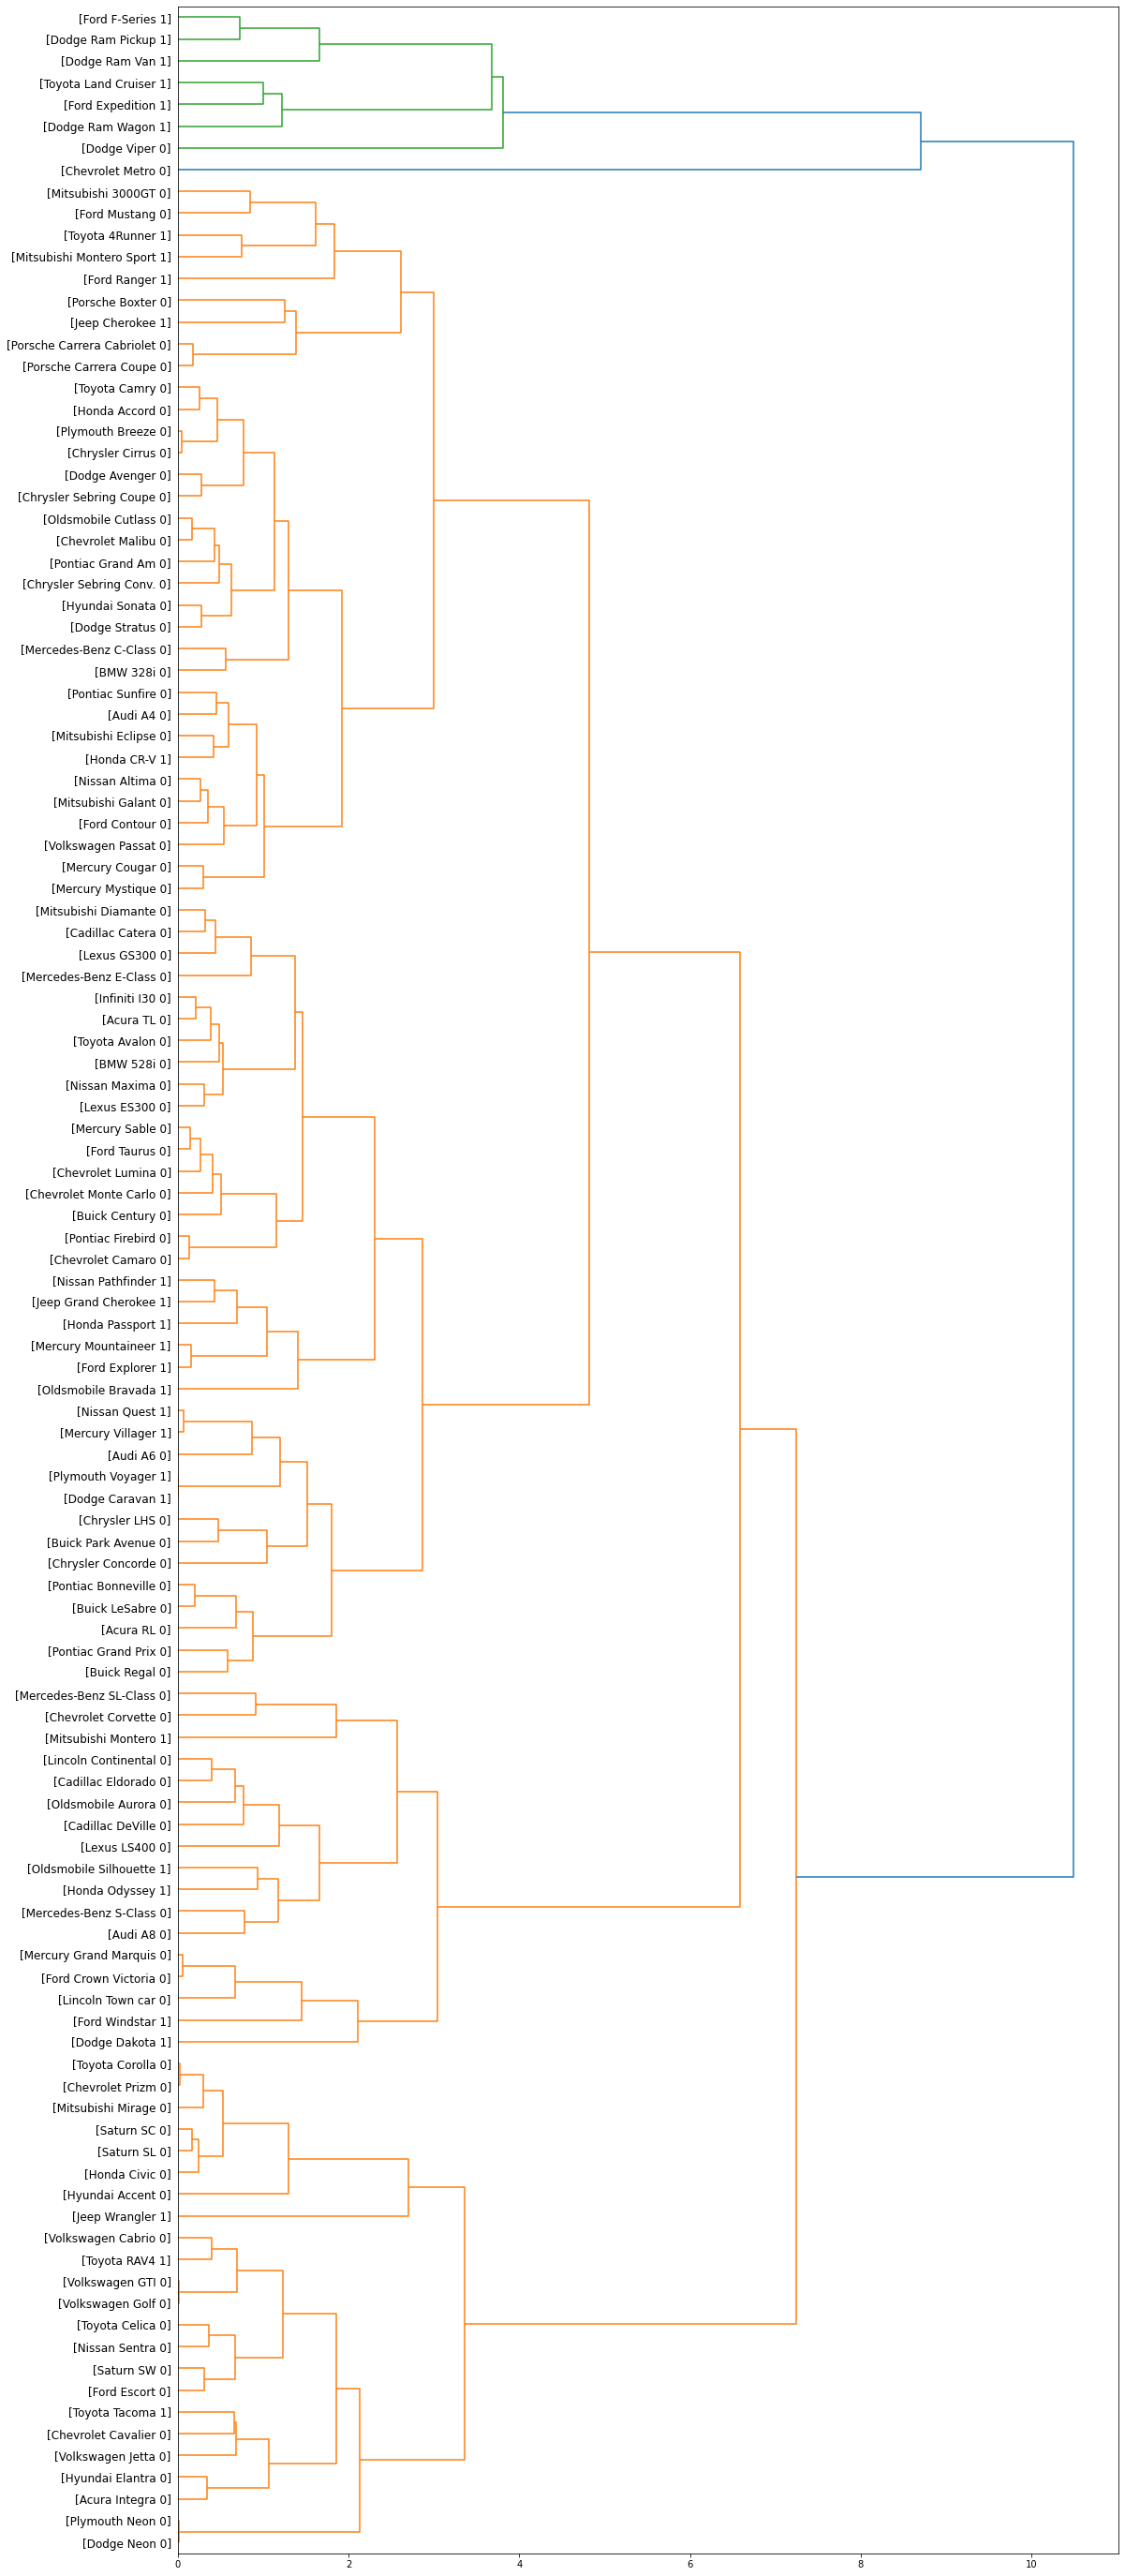

In [23]:
fig = pylab.figure(figsize=(18,50))

def llf(id):
    return '[%s %s %s]' % (df['manufact'][id],df['model'][id],int(float(df['type'][id])))

dendro = hierarchy.dendrogram(z,  leaf_label_func=llf, leaf_rotation=0, leaf_font_size =12, orientation = 'right')

## Clustering using scikit-learn

In [24]:
from sklearn.metrics.pairwise import euclidean_distances
dist_matrix=euclidean_distances(feature_mtx,feature_mtx)
print(dist_matrix)

[[0.         0.57777143 0.75455727 ... 0.28530295 0.24917241 0.18879995]
 [0.57777143 0.         0.22798938 ... 0.36087756 0.66346677 0.62201282]
 [0.75455727 0.22798938 0.         ... 0.51727787 0.81786095 0.77930119]
 ...
 [0.28530295 0.36087756 0.51727787 ... 0.         0.41797928 0.35720492]
 [0.24917241 0.66346677 0.81786095 ... 0.41797928 0.         0.15212198]
 [0.18879995 0.62201282 0.77930119 ... 0.35720492 0.15212198 0.        ]]


In [25]:
z_using_dist_matrix=hierarchy.linkage(dist_matrix,'complete')

C:\Users\bgc\AppData\Local\Temp/ipykernel_11188/2760980128.py:1: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  z_using_dist_matrix=hierarchy.linkage(dist_matrix,'complete')


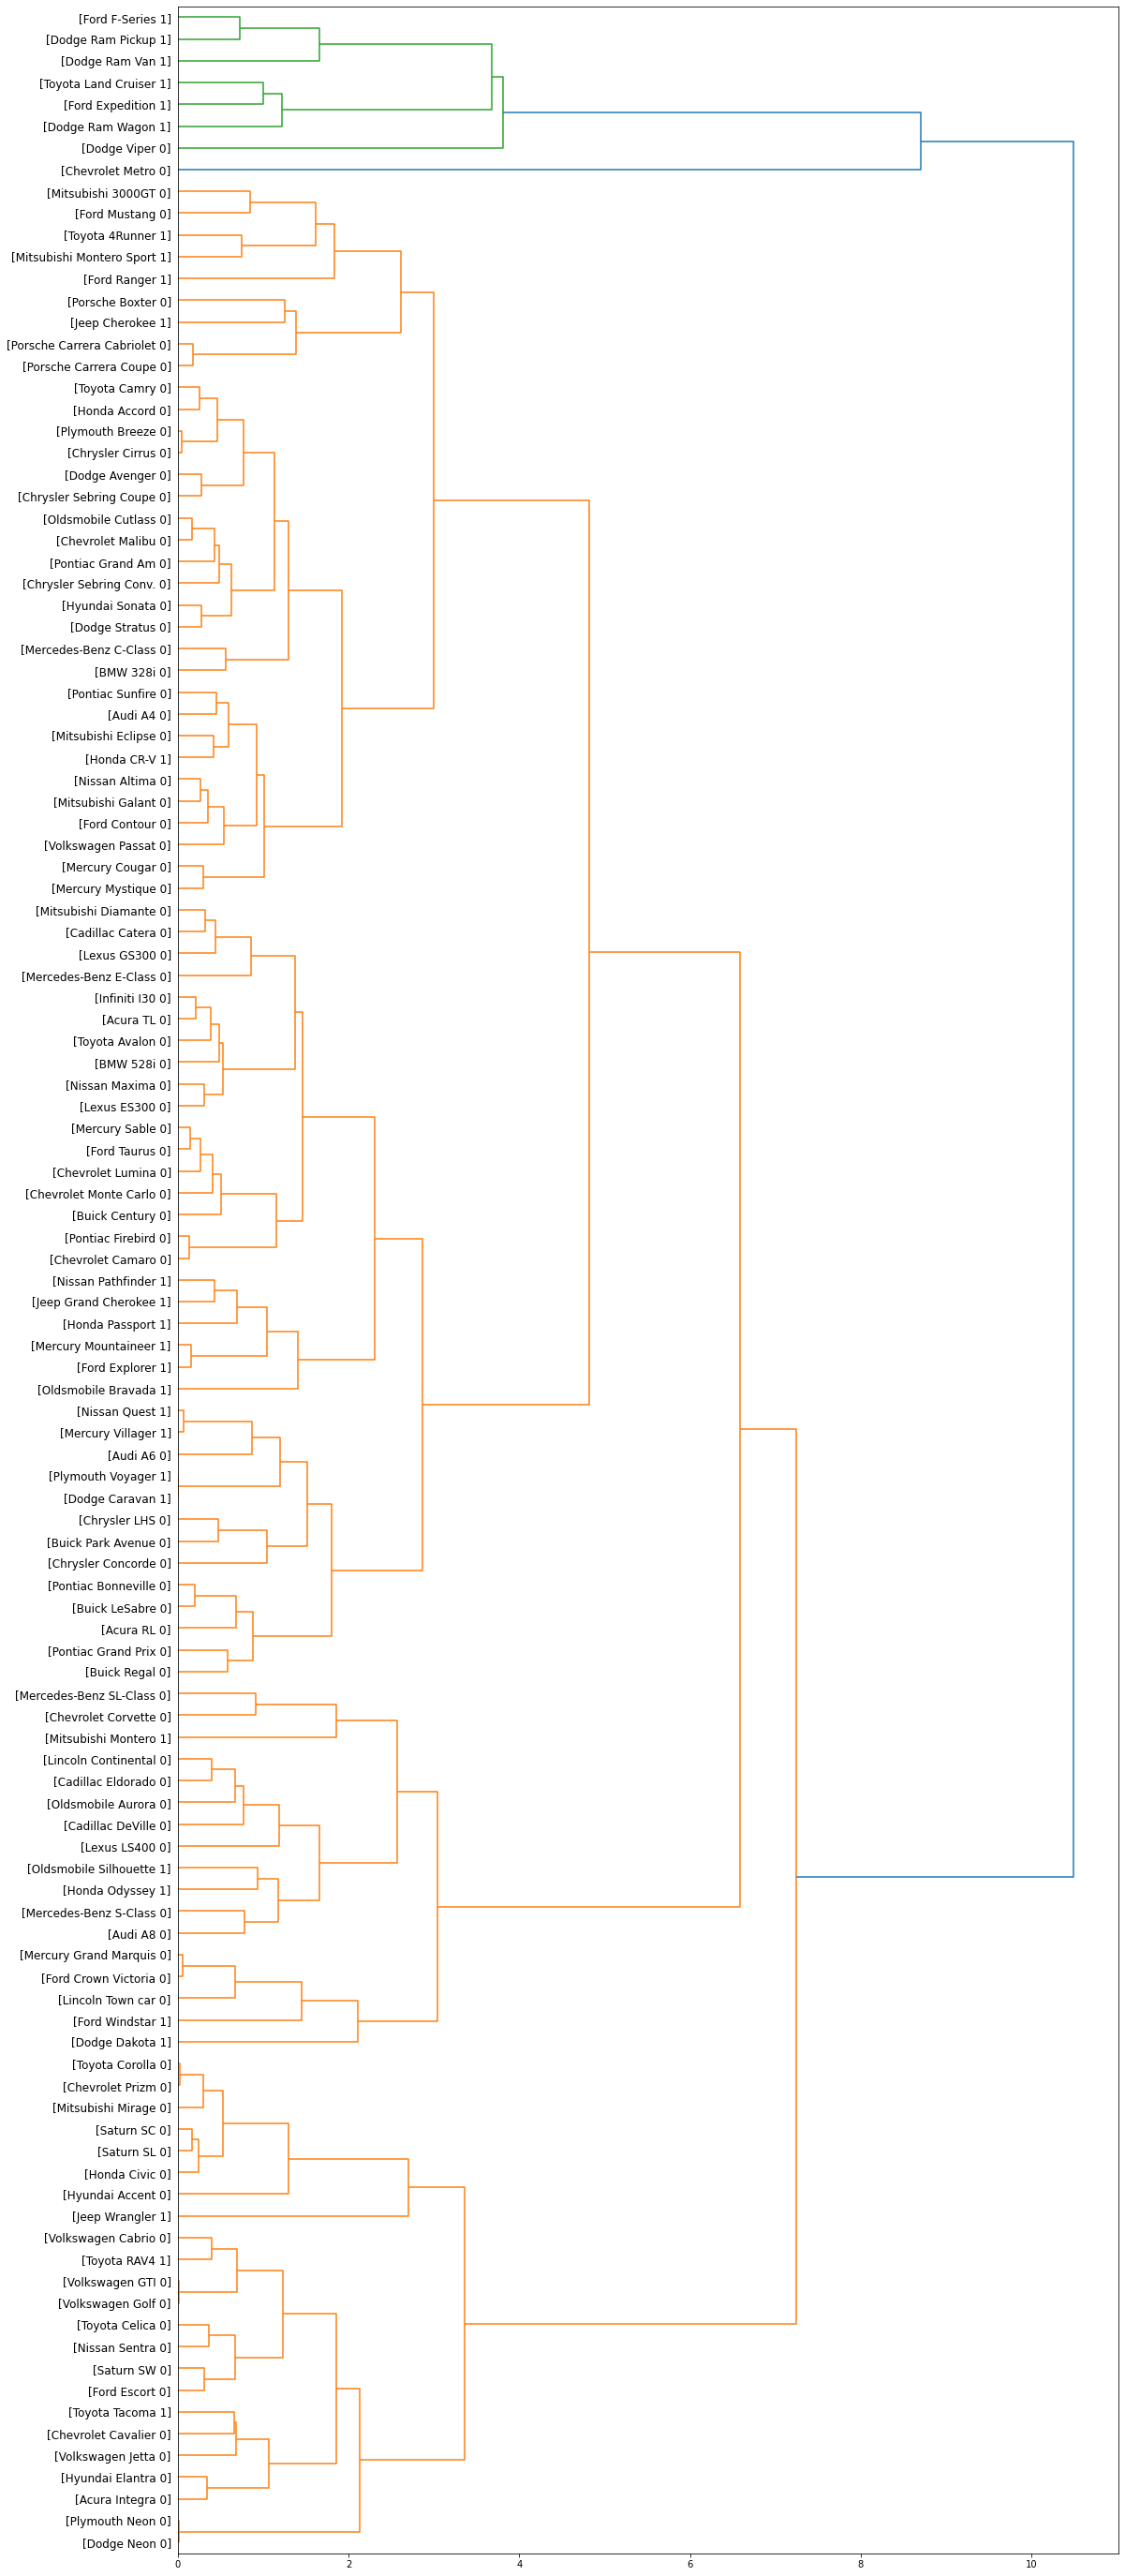

In [26]:
fig=pylab.figure(figsize=(18,50))
def llf(id):
    return '[%s %s %s]' % (df['manufact'][id],df['model'][id],int(float(df['type'][id])))

dendro=hierarchy.dendrogram(z_using_dist_matrix, leaf_label_func=llf, leaf_rotation=0, leaf_font_size=12, orientation='right')

In [27]:
model=AgglomerativeClustering(n_clusters=6,linkage='complete')
model.fit(dist_matrix)

model.labels_

C:\Users\bgc\anaconda3\lib\site-packages\sklearn\cluster\_agglomerative.py:493: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  out = hierarchy.linkage(X, method=linkage, metric=affinity)


array([1, 2, 2, 3, 2, 4, 3, 2, 2, 2, 2, 2, 4, 4, 2, 1, 3, 2, 2, 2, 4, 1,
       5, 3, 3, 2, 3, 2, 1, 3, 3, 0, 0, 0, 0, 4, 2, 1, 3, 3, 2, 4, 2, 4,
       0, 3, 0, 1, 3, 3, 2, 4, 1, 1, 3, 2, 1, 3, 2, 2, 2, 4, 4, 4, 1, 3,
       3, 2, 3, 4, 3, 3, 3, 2, 4, 2, 2, 3, 2, 4, 4, 1, 3, 2, 2, 2, 3, 4,
       2, 4, 1, 3, 2, 3, 3, 2, 2, 2, 3, 3, 3, 1, 1, 1, 1, 3, 2, 1, 1, 1,
       3, 0, 1, 1, 3, 1, 1], dtype=int64)

In [28]:
df['cluster_']=model.labels_
df.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition,cluster_
0,Acura,Integra,16.919,16.360,0.0,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2.828,0.0,1
1,Acura,TL,39.384,19.875,0.0,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,3.673,0.0,2
2,Acura,RL,8.588,29.725,0.0,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2.150,0.0,2
3,Audi,A4,20.397,22.255,0.0,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,3.015,0.0,3
4,Audi,A6,18.780,23.555,0.0,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,2.933,0.0,2


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

Text(0, 0.5, 'mpg')

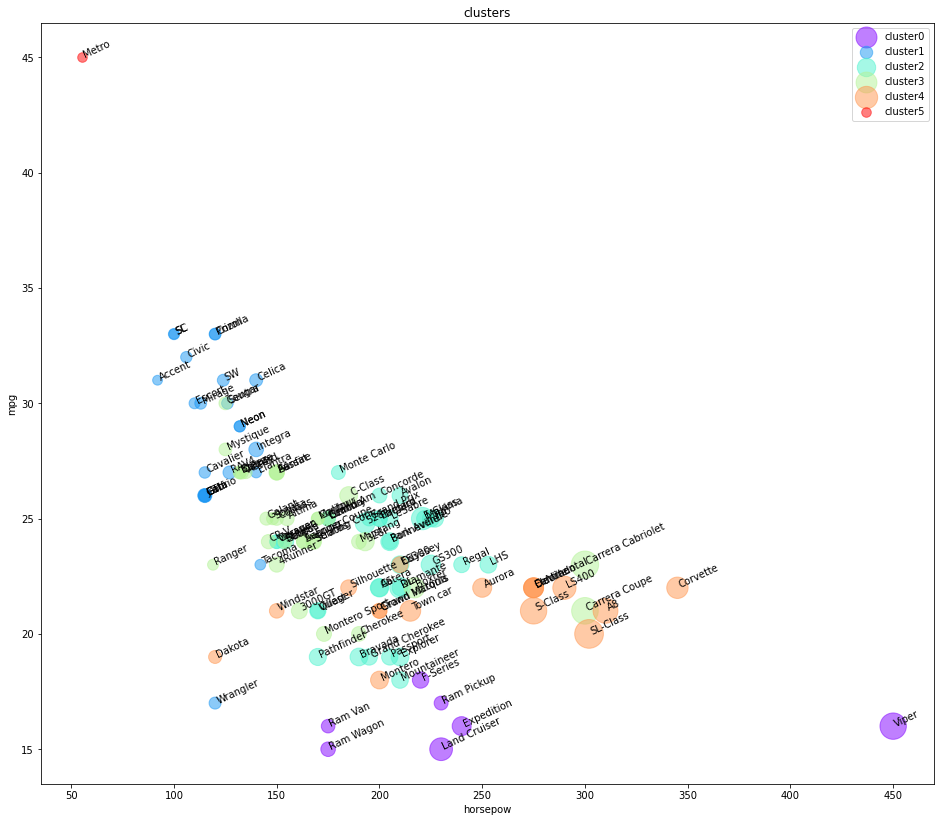

In [36]:
import matplotlib.cm as cm
n_clusters= max(model.labels_)+1
colors=cm.rainbow(np.linspace(0,1,n_clusters))
cluster_labels=list(range(0,n_clusters))

plt.figure(figsize=(16,14))

for color,label in zip(colors,cluster_labels):
    subset=df[df.cluster_==label]
    for i in subset.index:
        #plt.text(subset.horsepow[i], subset.mpg[i],str(subset['model'][i]), rotation=25) 
        plt.text(subset.horsepow[i], subset.mpg[i], str(subset['model'][i]), rotation=25)
    plt.scatter(subset.horsepow,subset.mpg,s=subset.price*10,c=color,label='cluster'+str(label),alpha=0.5)

plt.legend()
plt.title('clusters')
plt.xlabel('horsepow')
plt.ylabel('mpg')


 the distribution of each cluster use the scatter plot, but it is not very clear where is the centroid of each cluster. Moreover, there are 2 types of vehicles in our dataset, "truck" (value of 1 in the type column) and "car" (value of 0 in the type column). So, we use them to distinguish the classes, and summarize the cluster. First we count the number of cases in each group:


In [37]:
df.groupby(['cluster_','type'])['cluster_'].count()

cluster_  type
0         0.0      1
          1.0      6
1         0.0     20
          1.0      3
2         0.0     26
          1.0     10
3         0.0     28
          1.0      5
4         0.0     12
          1.0      5
5         0.0      1
Name: cluster_, dtype: int64

In [38]:
agg_cars=df.groupby(['cluster_','type'])['horsepow','engine_s','mpg','price'].mean()
agg_cars

C:\Users\bgc\AppData\Local\Temp/ipykernel_11188/2285101927.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  agg_cars=df.groupby(['cluster_','type'])['horsepow','engine_s','mpg','price'].mean()


horsepow  engine_s        mpg      price
cluster_ type                                            
0        0.0   450.000000  8.000000  16.000000  69.725000
         1.0   211.666667  4.483333  16.166667  29.024667
1        0.0   118.500000  1.890000  29.550000  14.226100
         1.0   129.666667  2.300000  22.333333  14.292000
2        0.0   203.615385  3.284615  24.223077  27.988692
         1.0   182.000000  3.420000  20.300000  26.120600
3        0.0   168.107143  2.557143  25.107143  24.693786
         1.0   155.600000  2.840000  22.000000  19.807000
4        0.0   267.666667  4.566667  21.416667  46.417417
         1.0   173.000000  3.180000  20.600000  24.308400
5        0.0    55.000000  1.000000  45.000000   9.235000

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

"\nloc[(label,),]=\nsince we performed grouping with['cluster_','type'], \nagg_cars has a multiIndex first cluster_  and second type\n\nloc[(label,),]= returns all rows where cluster=0\n"

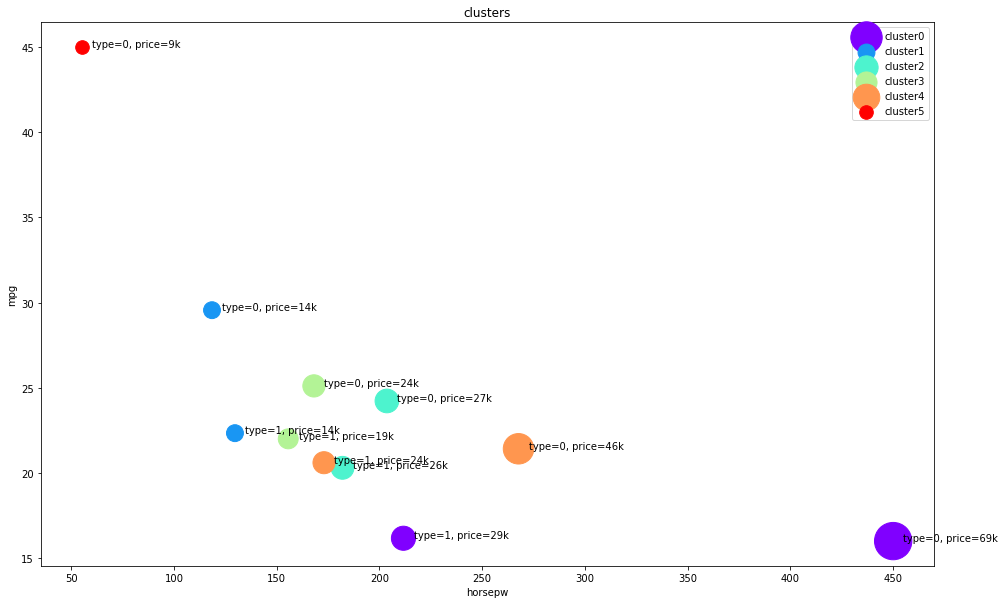

In [44]:
plt.figure(figsize=(16,10))
for color, label in zip (colors, cluster_labels):
    subset=agg_cars.loc[(label,),] 
    for i in subset.index:
        plt.text(subset.loc[i][0]+5, subset.loc[i][2], 'type='+str(int(i)) + ', price='+str(int(subset.loc[i][3]))+'k' )
    plt.scatter(subset.horsepow, subset.mpg, s=subset.price*20, c=color,label='cluster' +str(label))

plt.legend()
plt.title('clusters')
plt.xlabel('horsepw')
plt.ylabel('mpg')
'''
loc[(label,),]=
since we performed grouping with['cluster_','type'], 
agg_cars has a multiIndex first cluster_  and second type

loc[(label,),]= returns all rows where cluster=0
'''
